In [84]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

**Load Data**

In [85]:
df_original = pd.read_csv('Children Recode_final.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10,Malnurished
0,17,1,14,0,1,2,22.00,1,1,2,...,1,0,0,0,0,0,0,0,0,0
1,40,2,17,1,2,2,25.10,2,2,1,...,0,0,0,0,0,0,1,0,0,1
2,59,2,17,1,2,2,25.10,2,2,2,...,0,0,0,0,0,0,1,0,0,1
3,55,2,17,0,2,2,21.53,1,1,2,...,0,0,0,0,0,0,1,0,0,1
4,14,1,16,0,1,2,28.03,1,1,1,...,0,0,0,0,0,0,1,0,0,0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Child_age                  2239 non-null   int64  
 1   Mother_education           2239 non-null   int64  
 2   Age_first_sex              2239 non-null   int64  
 3   Pregnancy_terminated       2239 non-null   int64  
 4   Wealth_index               2239 non-null   int64  
 5   Place_residence            2239 non-null   int64  
 6   BMI                        2239 non-null   float64
 7   Children_under5            2239 non-null   int64  
 8   Total_children_ever_born   2239 non-null   int64  
 9   Child_sex                  2239 non-null   int64  
 10  Mother_age_current         2239 non-null   int64  
 11  Mother_age_at_first_birth  2239 non-null   int64  
 12  Father_education           2239 non-null   int64  
 13  Mother_working             2239 non-null   int64

In [87]:
df.shape

(2239, 35)

**Train-test Split**

In [88]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 12)

In [89]:
np.sum(y_train)

569

In [90]:
np.sum(y_test)

189

**Standard Scaler**

In [91]:
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [92]:
X_train_scaled.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
475,-0.014124,2,0.229651,1,4,2,-0.063844,2,1,2,...,0,0,0,0,0,0,0,1,0,0
1573,0.909059,0,1.157279,1,1,2,0.272522,2,2,2,...,0,1,0,0,0,0,0,0,0,0
2108,-1.745092,2,0.229651,0,3,1,-0.853012,0,1,2,...,0,1,0,0,0,0,0,0,0,0
714,-0.591113,1,1.157279,0,2,1,-0.586506,6,2,2,...,0,0,0,1,0,0,0,0,0,0
1412,-1.398898,2,-0.079558,0,4,1,-0.951335,2,1,1,...,0,0,0,0,0,0,0,1,0,0


**Visualize the PCA Results**

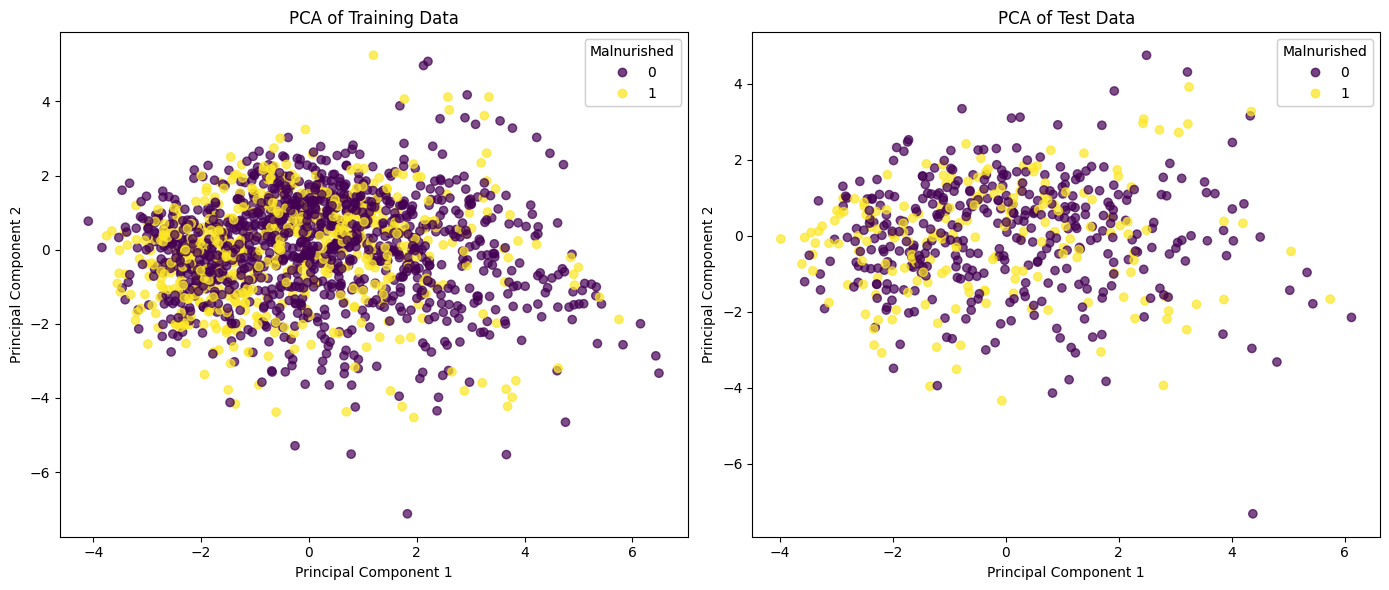

In [93]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for training data
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                                c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA of Training Data")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter_train.legend_elements(), title="Malnurished")
axes[0].add_artist(legend1)

# Plot for test data
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                               c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title("PCA of Test Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter_test.legend_elements(), title="Malnurished")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

**Balancing using SMOTE**

In [94]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 1110, 1: 569})
After SMOTE:  Counter({0: 1110, 1: 1110})


**Cross-validation for Best k**

In [95]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sm, y_train_sm, cv = 9, scoring='recall')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

Best k after balancing: 3, Accuracy: 0.8884


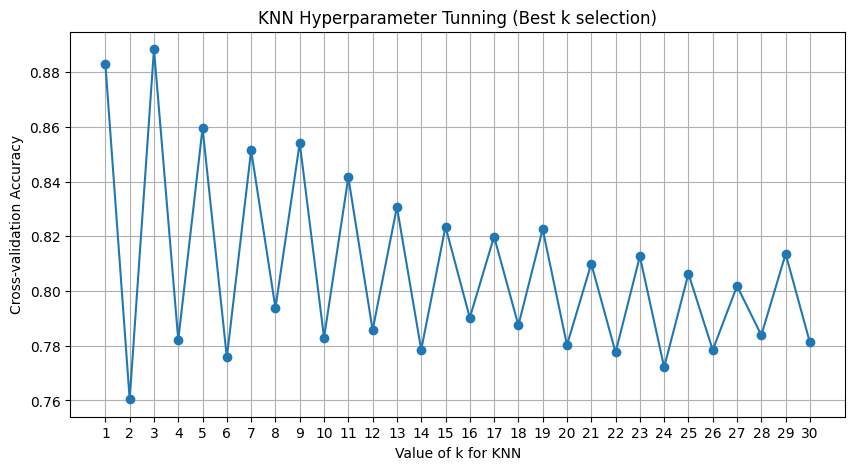

In [96]:
plt.figure(figsize=(10,5))
plt.plot(k_values, cv_scores, marker = 'o')
plt.xlabel('Value of k for KNN')
plt.ylabel('Cross-validation Accuracy')
plt.title('KNN Hyperparameter Tunning (Best k selection)')
plt.xticks(range(1,31,1))
plt.grid(True)
plt.show()

**Model Fit**

In [97]:
knn_combined = KNeighborsClassifier(weights = 'distance', metric = 'manhattan', n_neighbors=1)
knn_combined.fit(X_train_sm, y_train_sm)
y_predict = knn_combined.predict(X_test_scaled)

print(accuracy_score(y_test, y_predict))
pd.crosstab(y_test, y_predict)

0.5642857142857143


col_0,0,1
Malnurished,,
0,222,149
1,95,94


**Model's Performance**

In [98]:
# Classification Report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.70      0.60      0.65       371
           1       0.39      0.50      0.44       189

    accuracy                           0.56       560
   macro avg       0.54      0.55      0.54       560
weighted avg       0.59      0.56      0.57       560



In [99]:
# ROC-AUC Score
auc = roc_auc_score(y_test, knn_combined.predict_proba(X_test)[:,1])
print(f'ROC-AUC Score: {auc:.4f}')

ROC-AUC Score: 0.5051


In [100]:
average_precision_score(y_test, y_predict)

0.36203513183965863

In [101]:
ap = average_precision_score(y_test, knn_combined.predict_proba(X_test_scaled)[:, 1])
print(f"Average Precision: {ap:.4f}")

Average Precision: 0.3620


Average Precision: 0.3620


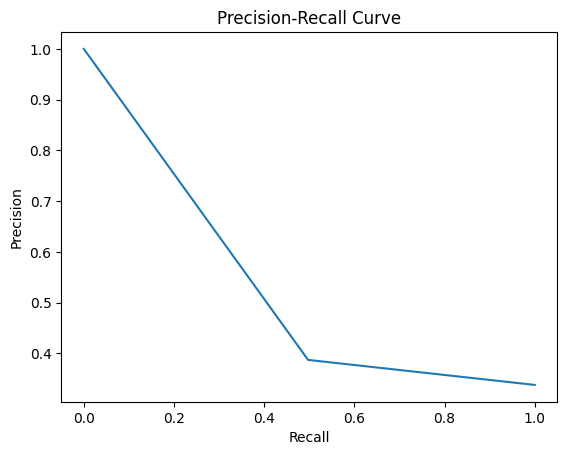

In [102]:
y_true = y_test  # True labels
y_scores = knn_combined.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class

# Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Compute Average Precision
ap = average_precision_score(y_true, y_scores)
print(f"Average Precision: {ap:.4f}")

# Plot Precision vs. Recall
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


ROC-AUC: 0.5479


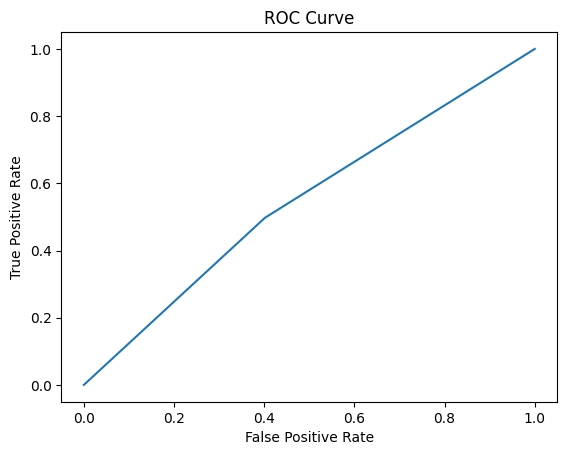

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Still using y_true and y_scores from above
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_true, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")

# Plot ROC Curve
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


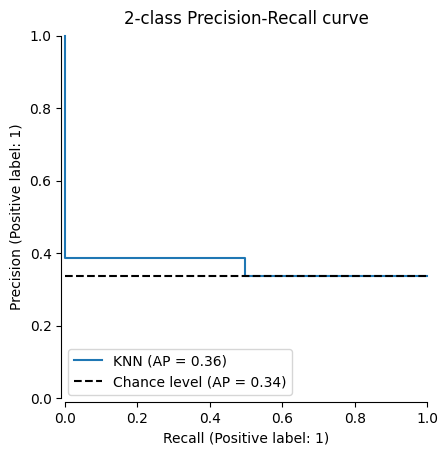

In [104]:
display = PrecisionRecallDisplay.from_estimator(
    knn_combined,         # trained model
    X_test_scaled,        # Test features
    y_test,               # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True,
)

_ = display.ax_.set_title("2-class Precision-Recall curve")


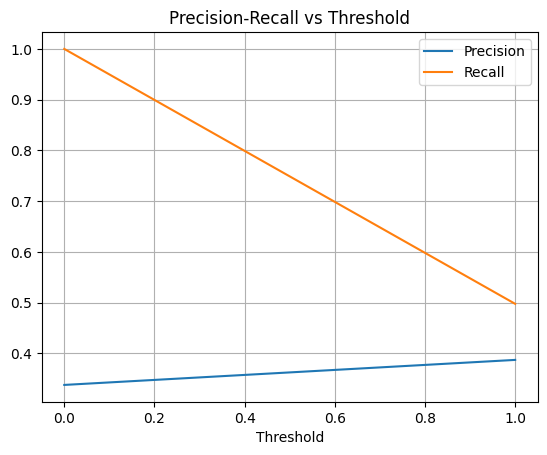

In [105]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_predict)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.show()

In [106]:
knn = KNeighborsClassifier(weights = 'distance', metric = 'manhattan', n_neighbors=5)
knn.fit(X_train_sm, y_train_sm)

y_predict = knn.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1

# Apply custom threshold
threshold = 0.30
y_pred_custom = (y_predict >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.69      0.29      0.41       371
           1       0.35      0.75      0.47       189

    accuracy                           0.44       560
   macro avg       0.52      0.52      0.44       560
weighted avg       0.57      0.44      0.43       560

